<div style="background-color:#ffecd2; color:#0f0c29; text-align:center; padding:15px; font-size:23px; border-radius:25px;">LAPTOP PRICE PREDICTION MODEL</div>

### Importing required libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


### Loading Dataset and Inspecting

In [32]:
df  = pd.read_csv(r'C:\Users\Dell\Downloads\archive (27)\laptops_uncleaned.csv', encoding = 'latin-1')
df

C:\Users\Dell\AppData\Local\Temp\ipykernel_12800\201417093.py:1: DtypeWarning: Columns (0: Model ID, 1: Data Rate, 2: Lifestyle, 3: Laptop Bag, 4: Model Name, 5: Screen Size, 6: Screen Type, 7: HDD Capacity, 8: Product Code, 9: Notebook Type, 10: Gaming Laptops, 11: Battery Back Up, 12: Operating System, 13: OS Architecture, 14: Lock Port, 15: Internal Mic, 16: Web Camera, 17: Pointer Device, 18: Variant, 19: Clock Speed, 20: Processor Brand, 21: System Architecture, 22: In Sales Package, 23: Return Policy, 24: Battery Cell, 25: Power Supply, 26: Antivirus, 27: Covered In Warranty, 28: Not Covered In Warranty, 29: Colour, 30: RAM Size, 31: Batteries, 32: Item Width, 33: Item Height, 34: Item Weight, 35: Processor Type, 36: Hard Drive Size, 37: Item Model Number, 38: Memory Technology, 39: Product Dimensions, 40: Included Components, 41: Graphics Coprocessor, 42: Hard Disk Technology, 43: Graphics Card Description, 44: Lithium Battery Energy Content, 45: eMMC Storage, 46: Display Port, 

,url,name,brand,price,ram_gb,storage_gb,cpu_tier,gpu_tier,weight_kg,primary_use_case,...,Recovery Options,Other Accessories,Wattage,Notebook Display Technology,ASIN,Customer Reviews,Date First Available,Number Of HDMI Ports,Maximum Memory Supported,EMMC Storage Capacity
0,https://www.smartprix.com/laptops/asus-br1100c...,Asus BR1100CKA-GJ0722W Laptop (Celeron N4500/ ...,Asus,29990,4,128,mid,integrated,1.26,business,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.smartprix.com/laptops/hp-business-...,HP Business Notebook HP250 (Intel Pentium M 20...,HP,27600,8,512,mid,integrated,1.80,student,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.smartprix.com/laptops/asus-rog-zep...,Asus ROG Zephyrus G14 GA401IHR-K2066TS Laptop ...,Asus,74990,8,1024,high,entry_gpu,1.60,gaming,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.smartprix.com/laptops/asus-vivoboo...,Asus VivoBook X515JA-EJ501T Laptop (10th Gen C...,Asus,37990,8,1024,mid,integrated,1.80,student,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.smartprix.com/laptops/hp-14s-cf304...,HP 14s-cf3047TU Laptop (10th Gen Core i3/ 4GB/...,HP,36739,4,256,entry,integrated,1.47,student,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16900,https://www.smartprix.com/laptops/samsung-gala...,Samsung Galaxy Book 4 NP750XGJ-KG3IN Laptop (I...,Samsung,66091,16,512,high,integrated,1.55,general,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16901,https://www.smartprix.com/laptops/acer-aspire-...,Acer Aspire 7 A715-51G UN.QGCSI.002 Gaming Lap...,Acer,66990,16,512,mid,entry_gpu,2.10,gaming,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16902,https://www.smartprix.com/laptops/hp-victus-15...,HP Victus 15-fa1062TX Gaming Laptop (13th Gen ...,HP,98000,16,512,mid,entry_gpu,2.37,gaming,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16903,https://www.smartprix.com/laptops/asus-x551ma-...,Asus X551MA-SX101D X Laptop(Pentium Quad Core/...,Asus,19990,2,500,mid,integrated,2.15,student,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df.info() # Checking datatypes

<class 'pandas.DataFrame'>
RangeIndex: 16905 entries, 0 to 16904
Columns: 272 entries, url to EMMC Storage Capacity
dtypes: float64(12), int64(3), object(4), str(253)
memory usage: 48.2+ MB


In [34]:
df.describe().round() # Checking numerical stats for each numerical feature

,price,ram_gb,storage_gb,weight_kg,Number Of USB 2 0 Ports,Number Of USB 3 0 Ports,Processor Count,USB 2 0 Slots,Bluetooth Version,Number Of Cores,USB 3 0 Slots,Number Of USB Ports,Number Of Lithium Ion Cells,RPM,Number Of HDMI Ports
count,16905.0,16905.0,16905.0,16905.0,6.0,1.0,7.0,3.0,3.0,5.0,2.0,2.0,2.0,7.0,1.0
mean,71768.0,10.0,693.0,2.0,2.0,2.0,2.0,1.0,4.0,4.0,2.0,3.0,4.0,5400.0,1.0
std,58989.0,7.0,351.0,12.0,1.0,NaN,1.0,0.0,0.0,3.0,1.0,0.0,2.0,0.0,NaN
min,6244.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,4.0,2.0,2.0,3.0,3.0,5400.0,1.0
25%,35658.0,4.0,512.0,2.0,1.0,2.0,2.0,1.0,4.0,2.0,2.0,3.0,4.0,5400.0,1.0
50%,54990.0,8.0,512.0,2.0,2.0,2.0,2.0,1.0,4.0,2.0,2.0,3.0,4.0,5400.0,1.0
75%,84990.0,16.0,1024.0,2.0,2.0,2.0,2.0,1.0,4.0,8.0,3.0,3.0,5.0,5400.0,1.0
max,729990.0,128.0,6144.0,899.0,2.0,2.0,4.0,1.0,4.0,8.0,3.0,3.0,6.0,5400.0,1.0


In [35]:
df.isnull().sum() # Checking number of counts of missing values in each feature/Column

url                             0
name                            0
brand                           0
price                           0
ram_gb                          0
                            ...  
Customer Reviews            16904
Date First Available        16904
Number Of HDMI Ports        16904
Maximum Memory Supported    16904
EMMC Storage Capacity       16904
Length: 272, dtype: int64

In [36]:
df.duplicated().sum() # Checking for duplicated rows

np.int64(0)

In [37]:
for col in df.columns:       # Checking for number of occurence of unique values in each column
    if df[col].nunique() < 50:
        print(f'Col Name: {col}')
        print(df[col].value_counts())
        print('-' * 50)

Col Name: ram_gb
ram_gb
8      7082
16     4391
4      3717
2       700
32      661
24      113
6       100
12       57
64       49
3         8
36        7
48        6
128       5
1         4
18        3
96        2
Name: count, dtype: int64
--------------------------------------------------
Col Name: storage_gb
storage_gb
512     7173
1024    5919
500     1778
256     1120
2048     282
128      215
750      125
64        89
32        82
320       67
640       14
16        10
4096       8
5120       4
1          4
240        3
120        2
8          2
6144       2
62         1
192        1
360        1
3072       1
60         1
480        1
Name: count, dtype: int64
--------------------------------------------------
Col Name: cpu_tier
cpu_tier
mid        8590
high       3822
entry      3754
premium     739
Name: count, dtype: int64
--------------------------------------------------
Col Name: gpu_tier
gpu_tier
integrated    10682
entry_gpu      5849
high_gpu        374
Name: count, dty

## Data Cleaning

### Selecting Useful Features

In [38]:
df = df.dropna(axis = 1, thresh = 10000) # Removing columns which don't have atleast 60% non-null values


In [39]:
cols = ['url','Ethernet','WiFi','Bluetooth','USB Ports','HDMI','Microphone In','Speakers','Speed','Cores','Sales Package','battery_performance','Cache','brand','Dimensions','Warranty','Headphone Jack','Camera','Inbuilt Microphone','weight_kg','ram_gb','cpu_tier','gpu_tier','Utility','Optical Drive','Touchpad','display','Keyboard','Battery','Type','Model','Series']
df = df.drop(columns = cols) # Removing useless columns

### Extracting Values

In [40]:
df.dropna(thresh = 14,inplace= True) # Removing row which have mostly empty values


In [41]:
import re

def value_interchange(l):
    l[0], l[1] = l[1], l[0] 
    return l
# Extracting numerical values from string datatype
df['Weight'] = (df['Weight'].apply(lambda x: x if isinstance(x,float) else re.findall(r'(-?\d+\.?\d*)', x)[0]))
df['Size'] =  df['Size'].apply(lambda x: x if isinstance(x, float) else re.findall(r'(-?\d+\.?\d*)',x)[0])
df['Resolution'] = (df['Resolution'].apply(lambda x: x if isinstance(x, float) else re.findall(r'(-?\d+x?\d+)',x)))
df['Resolution'] = df['Resolution'].apply(
    lambda x: x
    if isinstance(x, float)
    else (
        value_interchange(x)
        if len(x) == 2 and int(x[0]) < int(x[1])
        else x
    )
)
df['Resolution'] = df['Resolution'].apply(lambda x : x if isinstance(x, float) else 'x'.join(x))
df['PPI'] = df['PPI'].apply(lambda x: x if isinstance(x, float) else re.findall(r'(\d+)', x)[0])

### Handling Missing Values

In [42]:
''' Filling missing values and removing useless rows '''

df['OS'] = df['OS'].fillna(df['OS'].mode()[0])
df['Weight'] = df['Weight'].fillna(df['Weight'].astype('float').median())
df['Size'] = df['Size'].fillna(df['Size'].mode()[0])
df['Resolution'] = df['Resolution'].fillna(df['Resolution'].mode()[0])
df.loc[df['Resolution'].isin(['1080','']),'Resolution'] = df['Resolution'].mode()[0]
df['PPI'] = df['PPI'].fillna(df['PPI'].mode()[0])
df['Brand'] = df['Brand'].fillna('Others')
df['Brand'] = df['name'].apply(lambda x: x.split()[0])
df['Brand'] = df['Brand'].apply(lambda x: x if isinstance(x, float) else x.strip().lower())
df['GPU'] = df['GPU'].apply(lambda x: x if isinstance(x, float) else x.strip().lower())
df = df.drop(df[df['Brand'].isin(df['Brand'].value_counts().reset_index().loc[df['Brand'].value_counts().reset_index()['count'] < 24,'Brand'].tolist())].index) # Removing useless rows for prediction
df['RAM'] = df['RAM'].fillna(df['RAM'].mode()[0])
df['GPU'] = df['GPU'].fillna('Unknown')


In [43]:
''' Extracting appropriate Generation from processor'''

import pandas as pd
import re

def extract_generation(cpu):
    if pd.isna(cpu):
        return None

    cpu = str(cpu)

    # Intel Core generations
    m = re.search(r'(\d+)(?:st|nd|rd|th)\s+Gen', cpu, re.IGNORECASE)
    if m:
        return f"{m.group(1)}th Gen"

    # Intel Core Ultra Series
    m = re.search(r'Core\s+Ultra.*?Series\s+(\d+)', cpu, re.IGNORECASE)
    if m:
        return f"Core Ultra Series {m.group(1)}"

    # Intel Core / Core Ultra without "Series"
    if "Core Ultra" in cpu:
        return "Core Ultra"

    # AMD Ryzen generations
    m = re.search(r'(\d+)(?:st|nd|rd|th)\s+Gen\s+AMD\s+Ryzen', cpu, re.IGNORECASE)
    if m:
        return f"Ryzen {m.group(1)}th Gen"

    # Apple Silicon
    m = re.search(r'Apple\s+(M\d+\s*(?:Pro|Max|Ultra)?)', cpu, re.IGNORECASE)
    if m:
        return m.group(1)

    # Qualcomm Snapdragon X
    if "Snapdragon X Elite" in cpu:
        return "Snapdragon X Elite"

    if "Snapdragon X Plus" in cpu:
        return "Snapdragon X Plus"

    # Intel Pentium / Celeron / Atom
    if "Pentium" in cpu:
        return "Pentium"

    if "Celeron" in cpu:
        return "Celeron"

    if "Atom" in cpu:
        return "Atom"

    return "Unknown"

df["Generation"] = df["Processor"].apply(extract_generation)


### Fixing Inconsistent Formatting

In [44]:
''' Creating suitable dictionaries and then fixing inconsistent formatting '''


# Dictionaries
dict_gen = {'2th Gen' : '2nd Gen','3th Gen' : '3rd Gen'}
dict_reso = {}
dict_ram = { '3': '8','DDR5' : '8', '1' : '4' }
dict_reso.update(dict.fromkeys(['1366x767', '1366x766', '1366x762', '1366x760', '1366x728', '1366x720', '1366x786', '1368x768'],'1366x768'))
dict_reso.update({'1980x1080':'1920x1080','1920x1090':'1920x1080','2561x1600' :'2560x1600','2560x1660': '2560x1664' ,'3480x2160' :'3840x2160','3840x2060' :'3840x2160','3000x1876':'3000x1872'})
dict_reso.update(dict.fromkeys(['1966x1333','1920x1333','2296x1664','2408x1506','1080x920','2880x2880'],'1920x1080'))
dict_storage = {192 : 5120 ,8 : 256, 60: 256 , 62: 256,8: 6144, 1 : 256}
dict_ram_type = { 'LPDDR5x' : 'LPDDR5X', 'LPDDR4x' : 'LPDDR4X' , 'DDR3L' : 'DDR3', 'DDR4L' : 'DDR4','DDR' : "DDR4", 'â\x80\x8eDDR5' : 'DDR5', 'â\x80\x8eDDR4' : 'DDR4', 'â\x80\x8eLPDDR5x' :'LPDDR5X', 'â\x80\x8eDDR4': 'DDR4','â\x80\x8eLPDDR5x' : 'LPDDR5X', 'DDR4X' : 'LPDDR4X', 'â\x80\x8e' : 'DDR4', 'LPDDR5X-' : 'LPDDR5X','LPDDRx4' :'LPDDR4X', 'DDR6' : 'DDR4', 'SDR' :'DDR4', 'PDDR4' : 'LPDDR4X', 'DDr4X' :'DDR4', 'sLPDDR5' : 'LPDDR5X','2400' : 'DDR4','LPDD4' : 'LPDDR4X', 'DDR4-' : 'DDR4', 'LPDDR4X-' : 'LPDDR4X','LPDDR4x-' :'LPDDR4X', 'LDDR3' :'DDR3','GDDR4' :'DDR4'}
dict_os = {'Free': 'DOS','â\x80\x8eWindows 11' : 'Windows 11','Mac': 'macOS', 'â\x80\x8eWindows 10' : 'Windows 10', 'Linux/Ubuntu': 'Linux','Windows 10 Home':'Windows 10','Windows 10,': 'Windows 10', 'MacOS' : 'macOS', 'Chrome': 'ChromeOS','FreeDOS':'DOS', 'Endless': 'EndlessOS','â\x80\x8eChrome':'ChromeOS', 'None' :'Others', 'Unknown': 'Others', 'Windows 8 Pro,': 'Windows 8',
 'Express': 'Windows 11',
 'Windows 10 Pro,': 'Windows 10',
 'Chrome 64': 'ChromeOS',
 'Red': 'Windows 11',
 'DOS 2.0': 'DOS',
 'Windows10': 'Windows 10',
 'Apple': 'macOS',
 'Chrome,': 'ChromeOS',
 'OS': 'macOS',
 'â\x80\x8eWindows': 'Windows',
 'Windows Win11': 'Windows',
 'Windows 10.1': 'Windows',
 'Ubuntu/Linux': 'Linux',
 'FreeDOS 2.0': 'DOS',
 'Android v4.2': 'ChromeOS',
 'Google': 'ChromeOS',
 'Windows 11Home': 'Windows 11',
 'Windows 10 Home,': 'Windows 10',
 int(3):'Windows 10',
 'DOS,': 'DOS'}


# Reindexing dataframe
df = df.reset_index()
df = df.drop(columns= ['index'])


# Extracting important infomation from existing features
df['RAM_Type'] = df['RAM'].apply(lambda x: x.split()[2] if len(x.split()) == 3 else 'Unknown')


# Applying dictionaries on features
df['storage_gb'] = df['storage_gb'].replace(dict_storage)
df['Generation'] = df['Generation'].apply(lambda x: x.strip()).replace(dict_gen)
df['Resolution'] = df['Resolution'].replace(dict_reso)
df['Size'] = df['Size'].apply(lambda x : str(np.round(float(x))) if x in ([
    "7", "9.9", "10.95", "11.49", "11.98",
    "13.17", "13.51", "13.86", "13.96", "13.97",
    "14.22", "14.96",
    "15.25", "15.28", "15.35", "15.56", "15.59", "15.75", "15.84",
    "17.26", "17.32", "17.57",
    "18.39", "21"
]) else x )
df['OS'] = (df['OS'].apply(lambda x: (' '.join(x.split()[0:2]))).apply(lambda x : (x.split()[0]) if len(x.split()) ==2 and x.split()[1].isalpha() else x).apply(lambda x: 'Windows ' + x if  x.split()[0].strip(',').isdigit() else x)).apply(lambda x: x.split()[0] if '(64-bit)' in x  or '(32-bit)' in x and len(x.split()) == 2  else x)
df['OS'] = df['OS'].replace(dict_os)
df['RAM'] = df['RAM'].apply(lambda x: x.split()[0] if len(x.split()) > 1 else x)
df['RAM'] = df.apply(lambda x : '16' if x['RAM'] == '2' and (x['price']) > 35000 else x['RAM'],axis = 1)
df['RAM_Type'] = df['RAM_Type'].replace(dict_ram_type)
df['RAM'] = df['RAM'].replace(dict_ram)
df = df.drop(df.loc[df['RAM_Type'] == 'DDR2'].index)
df['Brand'] = df['Brand'].apply(lambda x: x.capitalize())
df['primary_use_case'] = df['primary_use_case'].apply(lambda x: x.capitalize())


In [45]:
# extracting gpu info and removing useless features

from gpu_extractor import extract_gpu
df = extract_gpu(df, col="GPU")
df = df.drop(columns  = ['GPU_Company','GPU_Family','GPU'])

In [46]:
df.describe()

,price,storage_gb
count,14577.000000,14577.000000
mean,75686.483844,723.233176
std,60401.752467,367.466238
min,6244.000000,16.000000
25%,38499.000000,512.000000
50%,58999.000000,512.000000
75%,89500.000000,1024.000000
max,729990.000000,6144.000000


### Handling Duplicates

In [47]:
df = df.drop([10252, 11182])

### Correcting Datatypes

In [48]:
# Changing datatypes according to the behavior of features

df['Weight'] = df['Weight'].astype(float)
df['Size'] = df['Size'].astype(float)
df['PPI'] = df['PPI'].astype(int)
df['RAM'] = df['RAM'].astype(int)


### Handling Outliers

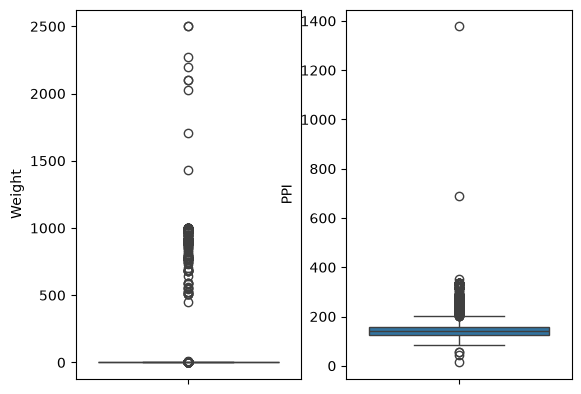

In [49]:
# Plotting boxplots to show outliers 

cols  = ['Weight','PPI']
for i, col in enumerate(cols,1):
    plt.subplot(1,2,i)
    sns.boxplot(df[col])

In [50]:
# Using IQR method for hanlding outliers

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_limit, upper_limit)
    

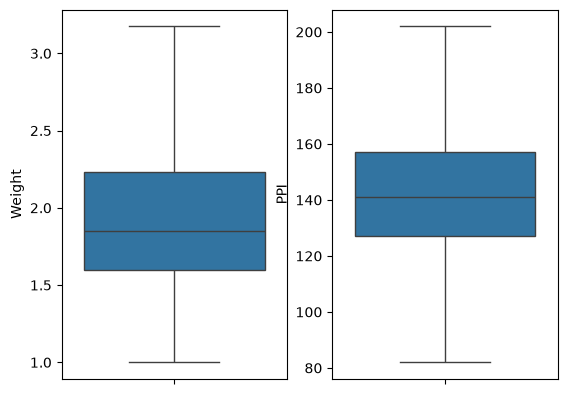

In [51]:
# Checking outliers after handling them

for i, col in enumerate(cols,1):
    plt.subplot(1,2,i)
    sns.boxplot(df[col])

In [52]:
# There are no outliers present in the data

In [53]:
df.to_csv(r'laptop_price_data_cleaned.csv',index = False) # Saving cleaned dataset

### Feature Engineering

In [54]:
df['Storage_Type'] = df['name'].str.lower().apply(lambda x: 'SSD' if 'ssd' in x else ('HDD' if 'hdd' in x else ('eMMC' if 'emmc' in x else ('nvme' if 'NVMe' in x else 'Unknown'))))

df['Processor'] = (
    df['name']
    .str.extract(r'\(([^()]*)\)\s*$')[0]   # Last brackets ke andar ka text
    .str.split('/')
    .str[0]
    .str.strip()
)

import re

# Processor Brand
def get_brand(x):
    x = str(x).lower()

    if "intel" in x or "core" in x or "celeron" in x or "pentium" in x or "xeon" in x:
        return "Intel"

    elif "amd" in x or "ryzen" in x or "athlon" in x:
        return "AMD"

    elif "apple" in x or "m1" in x or "m2" in x or "m3" in x or "m4" in x:
        return "Apple"

    elif "snapdragon" in x:
        return "Qualcomm"

    else:
        return "Unknown"


# Processor Family
def get_family(x):
    x = str(x).lower()

    if "core ultra 9" in x:
        return "Core Ultra 9"
    elif "core ultra 7" in x:
        return "Core Ultra 7"
    elif "core ultra 5" in x:
        return "Core Ultra 5"

    elif "core i9" in x or "ci9" in x:
        return "Core i9"
    elif "core i7" in x or "ci7" in x:
        return "Core i7"
    elif "core i5" in x or "ci5" in x:
        return "Core i5"
    elif "core i3" in x or "ci3" in x:
        return "Core i3"

    elif "ryzen 9" in x:
        return "Ryzen 9"
    elif "ryzen 7" in x:
        return "Ryzen 7"
    elif "ryzen 5" in x:
        return "Ryzen 5"
    elif "ryzen 3" in x:
        return "Ryzen 3"

    elif "celeron" in x:
        return "Celeron"

    elif "pentium" in x:
        return "Pentium"

    elif "athlon" in x:
        return "Athlon"

    elif "m4" in x:
        return "Apple M4"
    elif "m3" in x:
        return "Apple M3"
    elif "m2" in x:
        return "Apple M2"
    elif "m1" in x:
        return "Apple M1"

    else:
        return "Other"


# Generation
def get_generation(x):
    x = str(x)

    match = re.search(r'(\d+)(st|nd|rd|th)\s*gen', x, flags=re.I)

    if match:
        return match.group(1)

    return "Unknown"


# Processor Model
def get_model(x):
    x = str(x)

    match = re.search(r'(N\d+|\d{4,5}[A-Z]{0,3}|M1|M2|M3|M4|X Elite)', x, flags=re.I)

    if match:
        return match.group(1)

    return "Unknown"


# Create New Columns
df["Processor_Brand"] = df["Processor"].apply(get_brand)
df["Processor_Family"] = df["Processor"].apply(get_family)


In [55]:
# Removing useless features
df = df.drop(columns = ['name','Processor'])

In [56]:
# Data after Feature Enginnering
df.to_csv('laptop_price_prediction_cleaned_fe.csv',index = False)
df['price'] = df['price'].replace({'Unknown' : 'SSD'})


### Trian/Test Split

In [57]:
X = (np.array(df.drop(columns= ['price'])))
y = np.log(np.array(df['price']))

In [58]:
X_train, X_test, y_train ,y_test = train_test_split(X,y, test_size = 0.20, random_state= 42,shuffle = True)


### Feature Encoding and Model Training

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder

In [60]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor



In [61]:
''' Encoding and training using pipelines '''

# Step 1:
step1 = ColumnTransformer(transformers=[(
    'col_tnf', OneHotEncoder(handle_unknown= 'ignore',sparse_output = False, drop = 'first'),[1,2,4,8,9,12,15,16,]),(
        'target',TargetEncoder(),[6,11,13,14,17]
    )
],remainder= 'passthrough')


# Step 2:
step2 =RandomForestRegressor(
    n_estimators=800,
       max_depth=25,
       min_samples_split=5,
       bootstrap = True,
       min_samples_leaf=2,
       max_features="sqrt",
       random_state=42,
       n_jobs=-1
)

# Combining steps:
pipe = Pipeline([
    ('step1' ,step1),
    ('step2', step2)
])

# Model Training and evaluation
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
print('R2 score: ',r2_score(y_test,y_pred))
print('Training Score: ',pipe.score(X_train, y_train))
print('Testing Score: ',pipe.score(X_test, y_test))
print('MAE: ',mean_absolute_error(y_test, y_pred))

R2 score:  0.8812104549254367
Training Score:  0.9328048627631701
Testing Score:  0.8812104549254367
MAE:  0.15291889756006752


### Hyperparameter Tuning

In [62]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

''' Using RandomizedSearchCV for hyperparameter tuning  '''

params = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', 0.7],
    'max_samples': [0.7, 0.8, 0.9]
}



# Step 1:
step1 = ColumnTransformer(transformers=[(
    'col_tnf', OneHotEncoder(handle_unknown= 'ignore',sparse_output = False, drop = 'first'),[1,2,4,8,9,12,15,16,]),(
        'target',TargetEncoder(),[6,11,13,14,17]
    )
],remainder= 'passthrough')


# Step 2:
step2 = RandomizedSearchCV(
    estimator= RandomForestRegressor(),
    param_distributions = params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)
# Combining steps:
pipe_hyp = Pipeline([
    ('step1' ,step1),
    ('step2', step2)
])

# Model Training and evaluation
pipe_hyp.fit(X_train,y_train)
print(pipe_hyp.named_steps['step2'].best_params_)
print(pipe_hyp.named_steps['step2'].best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'max_depth': 23, 'max_features': 0.7, 'max_samples': 0.9, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 295}
0.8946597586024048


### Results after Hyperparameter Tuning

In [63]:
# Step 1
step1= ColumnTransformer(transformers= [('one_hot_encoding' ,
                                          OneHotEncoder(sparse_output= False, handle_unknown= 'ignore',drop = 'first'),[1,2,4,8,9,12,15,16,]),
                                          ('target_enc',TargetEncoder(),[6,11,13,14,17])],remainder = 'passthrough')

# Step 2
step2 = RandomForestRegressor(
    n_estimators = 295,
    max_depth = 23,
    max_features = 0.7,
    max_samples = 0.9,
    min_samples_leaf = 1,
    min_samples_split = 5,
    random_state = 42,
    n_jobs = -1
)
pipe_af_hyp = Pipeline([('step1',step1),('step2',step2)])
pipe_af_hyp.fit(X_train, y_train)

# Model Training after apply hyperparameter tuning
pipe_af_hyp.fit(X_train,y_train)
y_pred = pipe_af_hyp.predict(X_test)
print('R2 score: ',r2_score(y_test,y_pred))
print('Training Score: ',pipe_af_hyp.score(X_train, y_train))
print('Testing Score: ',pipe_af_hyp.score(X_test, y_test))
print('MAE: ',mean_absolute_error(y_test, y_pred))

R2 score:  0.8830599844329424
Training Score:  0.9515990042483309
Testing Score:  0.8830599844329423
MAE:  0.15088480617825617


In [64]:
# It increased +0.0025 R² (about 0.25 percentage points)

### Exporting the Model

In [94]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe_af_hyp,open('pipe.pkl','wb'))